In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [43]:
fake = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NLP/Fake (1).xls')
true = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NLP/True (1).xls')

In [44]:
#skull = Image.open("/content/drive/MyDrive/Colab Notebooks/NLP/skull-icon (1).png")
#thumbs = Image.open("/content/drive/MyDrive/Colab Notebooks/NLP/thumbs-up (1).png")

In [45]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [46]:
fake["subject"].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [47]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [48]:
true["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [49]:
fake["category"]=1
true["category"]=0

In [50]:
fake.head()

,title,text,subject,date,category
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [51]:
true.head()

,title,text,subject,date,category
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [52]:
df= pd.concat((fake , true)).reset_index(drop=True)

In [53]:
df

,title,text,subject,date,category
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [54]:
df.category.value_counts()

,count
category,
1,23481
0,21417


/tmp/ipython-input-1277603589.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


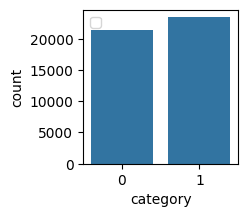

In [55]:
plt.figure(figsize=(2,2))
sns.countplot(x="category" , data= df)
plt.legend()

/tmp/ipython-input-309242301.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


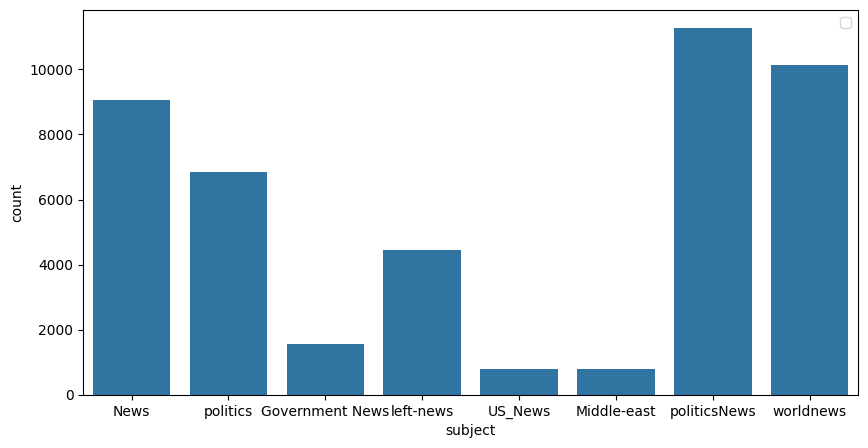

In [56]:
plt.figure(figsize=(10,5))
sns.countplot(x="subject" , data= df , )
plt.legend()

In [57]:
df = df[['text' , 'category']]
df

,text,category
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1
...,...,...
44893,BRUSSELS (Reuters) - NATO allies on Tuesday we...,0
44894,"LONDON (Reuters) - LexisNexis, a provider of l...",0
44895,MINSK (Reuters) - In the shadow of disused Sov...,0
44896,MOSCOW (Reuters) - Vatican Secretary of State ...,0


In [58]:
df.isna().sum()

,0
text,0
category,0


In [59]:
blanks = []

for index , text in df['text'].items():
  if text.isspace():
    blanks.append(index)
len(blanks)

631

In [60]:
blanks

[10923,
 11041,
 11190,
 11225,
 11236,
 11241,
 11247,
 11249,
 11267,
 11268,
 11283,
 11284,
 11285,
 11289,
 11290,
 11292,
 11295,
 11296,
 11301,
 11303,
 11304,
 11305,
 11309,
 11314,
 11317,
 11319,
 11322,
 11330,
 11334,
 11335,
 11340,
 11343,
 11348,
 11351,
 11352,
 11357,
 11371,
 11373,
 11374,
 11382,
 11397,
 11402,
 11403,
 11409,
 11410,
 11412,
 11415,
 11419,
 11421,
 11427,
 11431,
 11432,
 11440,
 11448,
 11450,
 11453,
 11462,
 11464,
 11465,
 11472,
 11473,
 11475,
 11478,
 11489,
 11491,
 11493,
 11494,
 11501,
 11505,
 11507,
 11520,
 11531,
 11532,
 11533,
 11538,
 11542,
 11547,
 11549,
 11551,
 11559,
 11563,
 11581,
 11585,
 11589,
 11590,
 11614,
 11624,
 11625,
 11627,
 11631,
 11636,
 11637,
 11643,
 11650,
 11658,
 11661,
 11672,
 11679,
 11681,
 11684,
 11686,
 11688,
 11692,
 11708,
 11718,
 11729,
 11739,
 11753,
 11765,
 11768,
 11777,
 11782,
 11786,
 11788,
 11792,
 11793,
 11803,
 11806,
 11813,
 11821,
 11831,
 11832,
 11841,
 11844,
 11848,


In [61]:
df['text'][10923]

' '

In [62]:
df.shape

(44898, 2)

In [63]:
df.drop(blanks , inplace=True)

/tmp/ipython-input-449871517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(blanks , inplace=True)


In [64]:
df.shape

(44267, 2)

In [65]:
import nltk
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import re

lemma = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [66]:
nlp = spacy.load('en_core_web_sm')
nltk.download('stopwords')
nlp = spacy.blank('en')

list1 = nlp.Defaults.stop_words
print("number of spacy ", len(list1))

list2 = set(stopwords.words('english'))
print("number of nltk ", len(list2))

stopwords = set(list1 | list2)
print("number of stopwords ", len(stopwords))


number of spacy  326
number of nltk  198
number of stopwords  401


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [67]:
#text cleaning function
def clean_text(text):

    """
    It takes text as an input and clean it by applying several methods

    """

    string = ""

    #lower casing
    text=text.lower()

    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)

    #removing any special character
    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=re.sub('[^A-Za-z0-9]+',' ', text)

    for word in text.split():
        if word not in stopwords:
            string+=lemma.lemmatize(word)+" "

    return string

In [68]:
df['text'] = df['text'].apply(clean_text)

/tmp/ipython-input-1163271480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)


In [70]:
df['text'][10]

'centerpiece donald trump campaign presidency white supremacist way public feud get involve people color favorite target course player national football league dare exercise amendment right kneeling national anthem protest racist police brutality person figured racism bad business orange overlord elected founder pizza chain papa john man right history number issue plus pizza suck decided complain player protesting sale dropped turn racism pay know corporation line papa john schnatter longer ceo hack pizza chain breaking papa john founder john schnatter step ceo announcement come week criticized nfl protest ap business news apbusiness december 21 2017the thing people certainly allowed political opinion realize opinion come dire consequence especially business trying garner sale support people presume goal ceo know pressure shareholder public outcry boycott nfl stepping right know gone future ceo run company inclusive diverse fabric america guiding symbol nation statue liberty bigot like

word cloud

In [71]:
from wordcloud import WordCloud

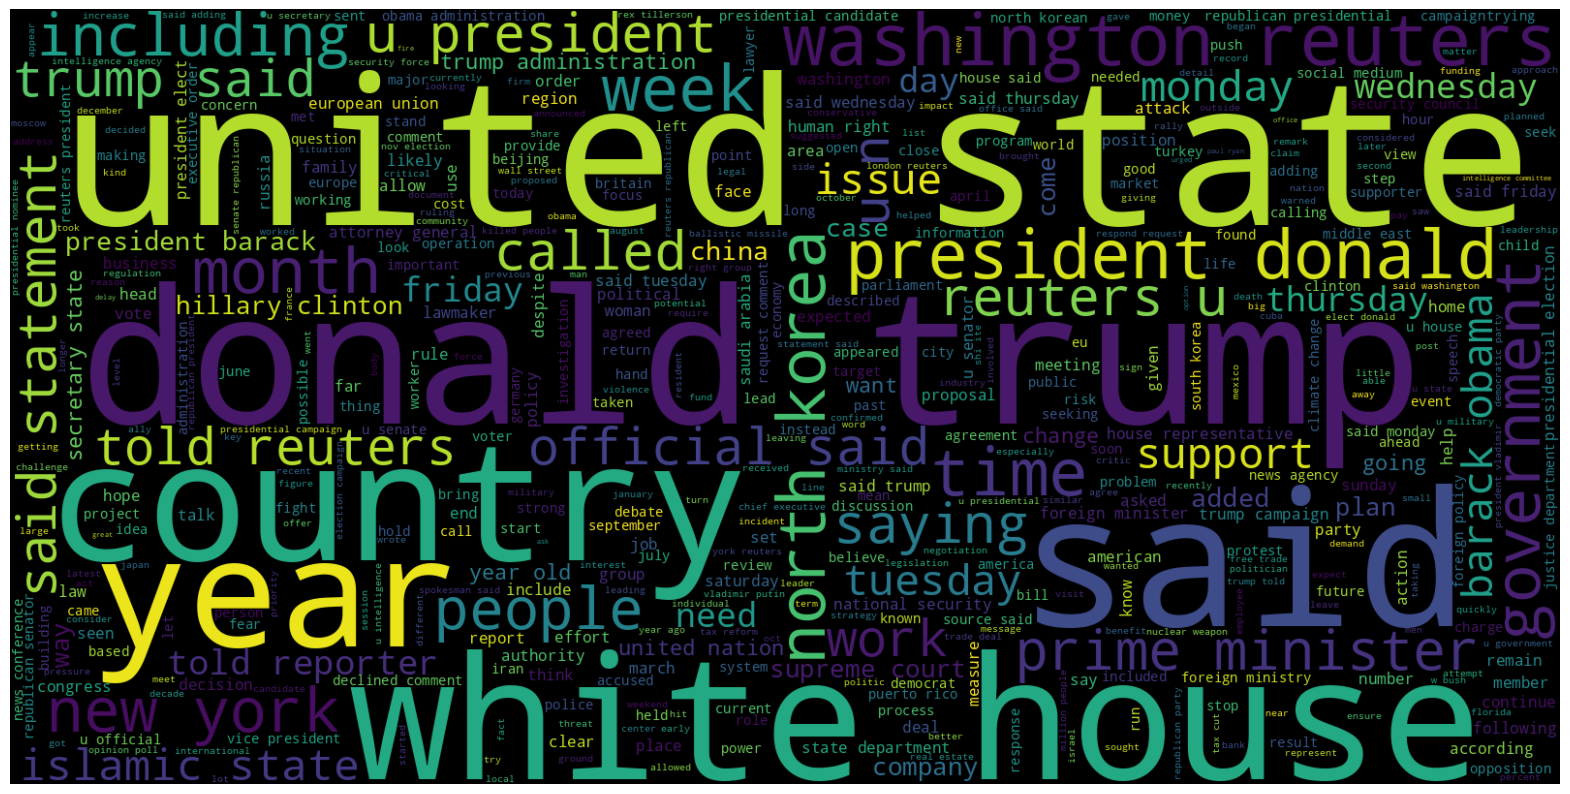

In [76]:
plt.figure(figsize=(20,20))
WC = WordCloud(max_words = 500 , width=1600 , height = 800).generate(" ".join(df[df.category==0].text))
plt.axis('off')
plt.imshow(WC , interpolation='bilinear')
plt.show()

In [77]:
#pil is pillow
from PIL import Image

In [80]:
thumd = '/content/drive/MyDrive/Colab Notebooks/NLP/thumbs-up (1).png'
icon  = Image.open(thumd)
mask = Image.new(mode='RGB' , size=icon.size , color=(255,255,255))
mask.paste(icon , box=icon)

rgb_array = np.array(mask)

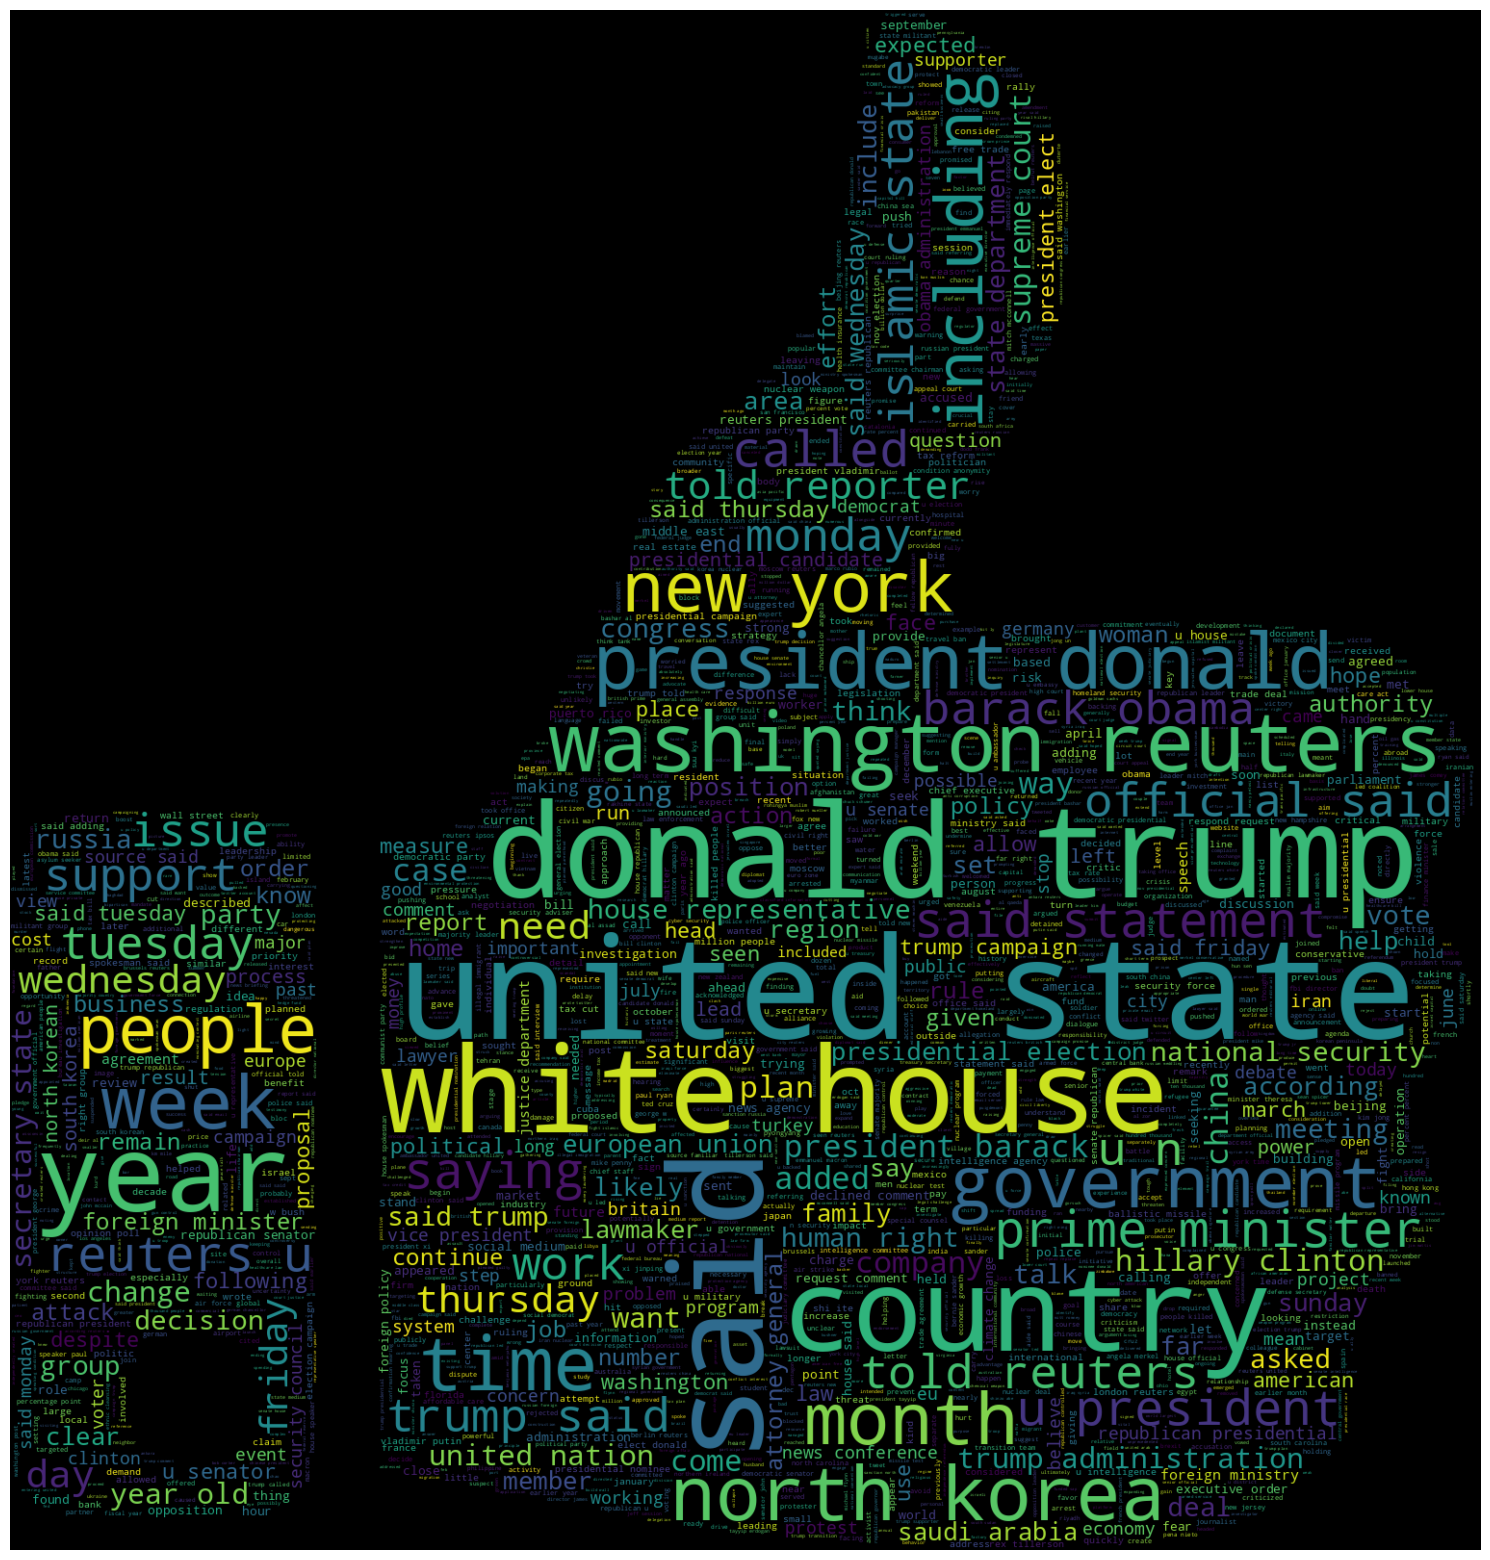

In [83]:
plt.figure(figsize = (20,20))
WC = WordCloud(mask=rgb_array , max_words =2000 , width=1600 , height = 800)
WC.generate(' '.join(df[df.category == 0].text))
plt.axis("off")
plt.imshow(WC , interpolation='bilinear')
plt.show()

In [84]:
skull = '/content/drive/MyDrive/Colab Notebooks/NLP/skull-icon (1).png'
icon  = Image.open(skull)
mask = Image.new(mode='RGB' , size=icon.size , color=(255,255,255))
mask.paste(icon , box=icon)

rgb_array = np.array(mask)

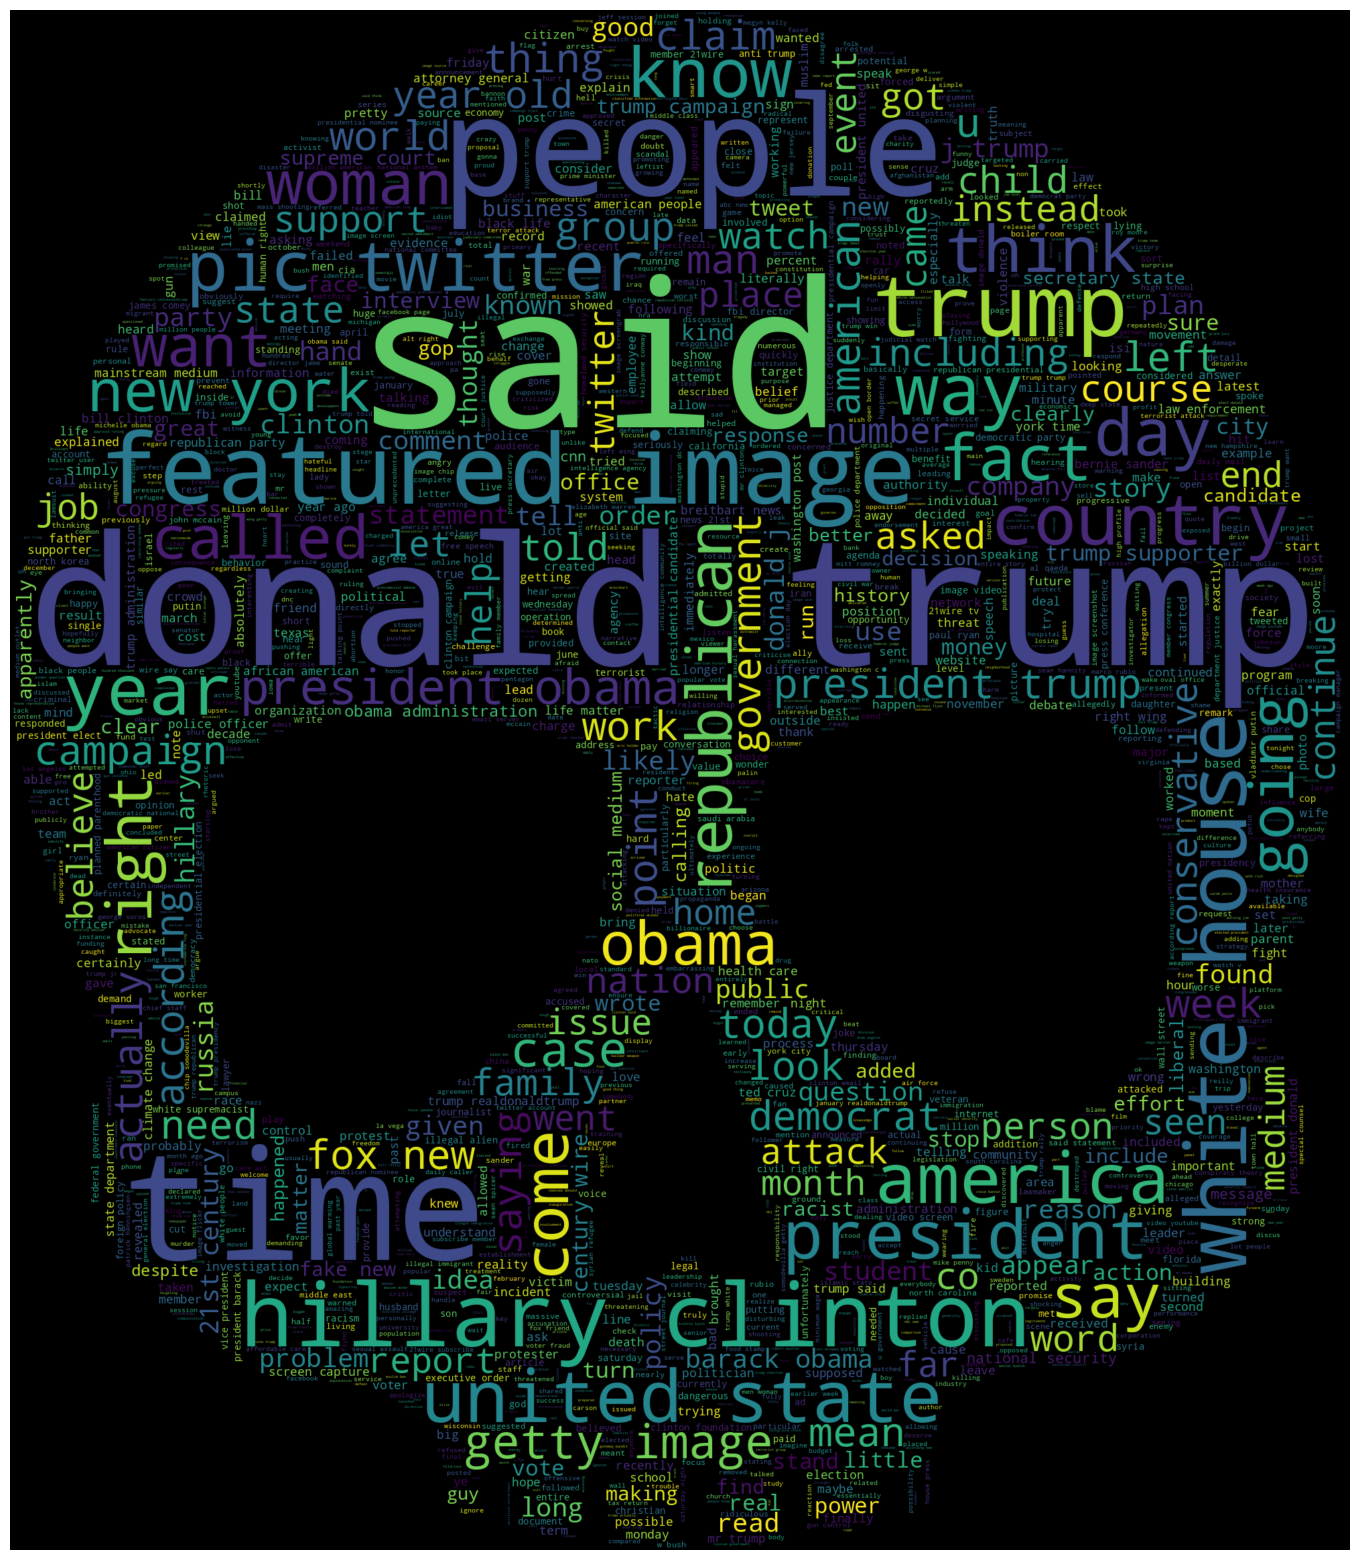

In [86]:
plt.figure(figsize = (20,20))
WC = WordCloud(mask=rgb_array , max_words =2000 , width=1600 , height = 800)
WC.generate(' '.join(df[df.category == 1].text))
plt.axis("off")
plt.imshow(WC , interpolation='bilinear')
plt.show()

In [87]:
from sklearn.model_selection import train_test_split

x = df['text']
y= df['category']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.33 , random_state=42)

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
vc = TfidfVectorizer()
x_train_tfidf = vc.fit_transform(x_train)



In [91]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [92]:
text_clf = Pipeline([('tfidf' , TfidfVectorizer()) , ('clf' , LinearSVC())])
text_clf.fit(x_train , y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score , classification_report

In [95]:
def model(model):

  y_pred1 = model.predict(x_test)
  print("accuracy_score :",accuracy_score(y_test , y_pred1))
  print("confusion_matrix :",confusion_matrix(y_test , y_pred1))
  print("precision_score :",precision_score(y_test , y_pred1))
  print(classification_report(y_test, y_pred1))


In [96]:
model(text_clf)

accuracy_score : 0.9932918064206996
confusion_matrix : [[7000   47]
 [  51 7511]]
precision_score : 0.9937814236570521
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7047
           1       0.99      0.99      0.99      7562

    accuracy                           0.99     14609
   macro avg       0.99      0.99      0.99     14609
weighted avg       0.99      0.99      0.99     14609

